# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** khatrunnada_salsabila_zega_6xAv
- **Email:** khatrunsalsabia@gmail.com
- **ID Dicoding:** CDCC889D6X1473

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi penjualan (revenue) tertinggi dan terendah selama periode dataset?
- **Pertanyaan 2:** Bagaimana tren penjualan bulanan dan kapan terjadi peningkatan atau penurunan signifikan?


## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

## Data Wrangling

### Gathering Data

#### Load Dataset dari ZIP File

In [4]:
import zipfile
import pandas as pd # Menambahkan import pandas karena digunakan di bagian bawah

zip_file_path = '/content/drive/MyDrive/test/E-commerce-public-dataset (1).zip'

# Membuka file ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Menampilkan daftar file di dalam ZIP
    print("Files in the ZIP archive:")
    zip_ref.printdir()

    # Membaca file CSV yang diharapkan (asumsi ada satu file CSV utama)
    # Anda mungkin perlu menyesuaikan nama file di sini jika ada lebih dari satu CSV atau nama berbeda
    # Contoh: 'E-commerce-public-dataset.csv' atau 'data.csv'
    try:
        # Mencari file CSV pertama di dalam zip
        csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
        if csv_files:
            main_csv_file = csv_files[0]
            print(f"\nLoading {main_csv_file} into a pandas DataFrame...")
            with zip_ref.open(main_csv_file) as csv_file:
                df = pd.read_csv(csv_file)
            print("Dataset loaded successfully!")
            display(df.head())
        else:
            print("No CSV files found in the ZIP archive.")
    except Exception as e:
        print(f"Error loading CSV from zip: {e}")


Files in the ZIP archive:
File Name                                             Modified             Size
E-Commerce Public Dataset/customers_dataset.csv 2023-03-07 10:13:38      9033957
E-Commerce Public Dataset/geolocation_dataset.csv 2023-03-07 10:13:38     61273883
E-Commerce Public Dataset/New Text Document.txt 2023-03-07 10:57:12            0
E-Commerce Public Dataset/order_items_dataset.csv 2023-03-07 10:13:38     15438671
E-Commerce Public Dataset/order_payments_dataset.csv 2023-03-07 10:13:38      5777138
E-Commerce Public Dataset/order_reviews_dataset.csv 2023-03-07 10:13:38     14451670
E-Commerce Public Dataset/orders_dataset.csv   2023-03-07 10:13:38     17654914
E-Commerce Public Dataset/product_category_name_translation.csv 2023-03-07 10:13:38         2613
E-Commerce Public Dataset/products_dataset.csv 2023-03-07 10:13:38      2379446
E-Commerce Public Dataset/sellers_dataset.csv  2023-03-07 10:13:38       174703

Loading E-Commerce Public Dataset/customers_dataset.csv i

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
import zipfile
import pandas as pd
import io

dataframes = {}

# Load all CSV files into a dictionary of DataFrames using only the filename as the key
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    for file_name in csv_files:
        # Extract only the filename without the path and extension
        df_name = file_name.split('/')[-1].replace('.csv', '')
        print(f"Loading {file_name} as '{df_name}'...")
        with zip_ref.open(file_name) as csv_file:
            try:
                dataframes[df_name] = pd.read_csv(csv_file)
            except UnicodeDecodeError:
                with zip_ref.open(file_name) as csv_file_retry:
                    dataframes[df_name] = pd.read_csv(csv_file_retry, encoding='latin1')
            print(f"'{df_name}' loaded successfully! Rows: {dataframes[df_name].shape[0]}")

print("\nAll CSV files loaded into separate DataFrames with clean keys.")

Loading E-Commerce Public Dataset/customers_dataset.csv as 'customers_dataset'...
'customers_dataset' loaded successfully! Rows: 99441
Loading E-Commerce Public Dataset/geolocation_dataset.csv as 'geolocation_dataset'...
'geolocation_dataset' loaded successfully! Rows: 1000163
Loading E-Commerce Public Dataset/order_items_dataset.csv as 'order_items_dataset'...
'order_items_dataset' loaded successfully! Rows: 112650
Loading E-Commerce Public Dataset/order_payments_dataset.csv as 'order_payments_dataset'...
'order_payments_dataset' loaded successfully! Rows: 103886
Loading E-Commerce Public Dataset/order_reviews_dataset.csv as 'order_reviews_dataset'...
'order_reviews_dataset' loaded successfully! Rows: 99224
Loading E-Commerce Public Dataset/orders_dataset.csv as 'orders_dataset'...
'orders_dataset' loaded successfully! Rows: 99441
Loading E-Commerce Public Dataset/product_category_name_translation.csv as 'product_category_name_translation'...
'product_category_name_translation' loaded

### Examining each DataFrame for issues

In [7]:
print("\n--- Data Assessment for All DataFrames ---")

for name, df in dataframes.items():
    print(f"\n--- DataFrame: {name} ---")
    print(f"Shape: {df.shape}")
    print("Info:")
    df.info()
    print("Missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing values
    print("Duplicate rows:")
    print(df.duplicated().sum())


--- Data Assessment for All DataFrames ---

--- DataFrame: customers_dataset ---
Shape: (99441, 5)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Missing values:
Series([], dtype: int64)
Duplicate rows:
0

--- DataFrame: geolocation_dataset ---
Shape: (1000163, 5)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 

**Insight:** (Opsional)
- Bagian ini fokus pada persiapan data, termasuk memuat dataset dari file ZIP, menggabungkan tabel yang berbeda, dan melakukan pemeriksaan awal seperti info(), isnull().sum(), dan duplicated().sum() untuk memahami struktur dan kualitas data.

### Assessing Data

In [14]:
# Periksa informasi dataset
print("\nDataset Info:")
df.info()

# Periksa nilai yang hilang
print("\nMissing values:")
print(df.isnull().sum())

# Periksa duplikat
print("\nDuplicate rows:")
print(df.duplicated().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Missing values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Duplicate rows:
0


#### Identifying ... problem

#### Identifying Data Quality Problems

In [8]:
# Based on the previous data assessment, we can identify the following problems:

# 1. orders_dataset:
#    - Missing values in 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'.
#    - 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date' are object type, but should be datetime.

# 2. products_dataset:
#    - Missing values in 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'.

# 3. sellers_dataset:
#    - No apparent issues (no missing values, no duplicates, data types seem correct).

# 4. order_items_dataset:
#    - 'shipping_limit_date' is object type, but should be datetime.

# 5. order_payments_dataset:
#    - No apparent issues.

# 6. order_reviews_dataset:
#    - Missing values in 'review_comment_title', 'review_comment_message'.
#    - 'review_creation_date' and 'review_answer_timestamp' are object type, but should be datetime.

# 7. geolocation_dataset:
#    - Duplicates (multiple entries for the same zip code prefix but different coordinates).

# 8. product_category_name_translation:
#    - No apparent issues.

# 9. customers_dataset:
#    - No apparent issues (no missing values, no duplicates, data types seem correct).


**Steps to Take:**
- **Handling Missing Values:** Fill or drop missing values in `orders_dataset`, `products_dataset`, and `order_reviews_dataset`.
- **Correcting Data Types:** Convert relevant columns to datetime objects in `orders_dataset`, `order_items_dataset`, and `order_reviews_dataset`.
- **Handling Duplicates:** Address duplicate entries in `geolocation_dataset` (e.g., by taking the mean or first occurrence for coordinates).
- **Merging DataFrames:** Combine all relevant dataframes into a single, comprehensive dataframe for easier analysis.

**Insight:**
- Beberapa dataset memiliki masalah kualitas data yang signifikan seperti nilai yang hilang dan tipe data yang tidak sesuai, terutama pada kolom tanggal dan informasi produk. Ini perlu diperbaiki sebelum analisis lebih lanjut.
- Dataset `geolocation_dataset` memiliki duplikasi data yang perlu ditangani untuk memastikan keakuratan informasi lokasi.
- Dataset `customers_dataset`, `sellers_dataset`, `order_payments_dataset`, dan `product_category_name_translation` terlihat bersih dari masalah dasar seperti nilai hilang atau duplikat.

### Cleaning Data

#### Fixing ... problem

In [9]:
# 1. Menangani tipe data datetime di berbagai dataset
datetime_columns = {
    'orders_dataset': ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
    'order_items_dataset': ['shipping_limit_date'],
    'order_reviews_dataset': ['review_creation_date', 'review_answer_timestamp']
}

for df_name, cols in datetime_columns.items():
    if df_name in dataframes:
        for col in cols:
            dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col])

# 2. Menangani nilai yang hilang (Missing Values)
# Menggunakan cara baru (assignment) untuk menghindari FutureWarning
if 'order_reviews_dataset' in dataframes:
    dataframes['order_reviews_dataset']['review_comment_title'] = dataframes['order_reviews_dataset']['review_comment_title'].fillna('No Title')
    dataframes['order_reviews_dataset']['review_comment_message'] = dataframes['order_reviews_dataset']['review_comment_message'].fillna('No Message')

if 'products_dataset' in dataframes:
    dataframes['products_dataset']['product_category_name'] = dataframes['products_dataset']['product_category_name'].fillna('unknown')
    columns_to_fill_zero = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
    for col in columns_to_fill_zero:
        dataframes['products_dataset'][col] = dataframes['products_dataset'][col].fillna(0)

# 3. Menangani Duplikat di geolocation_dataset
if 'geolocation_dataset' in dataframes:
    dataframes['geolocation_dataset'].drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first', inplace=True)

print("Data cleaning selesai.")

Data cleaning selesai.


**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
import pandas as pd

# EDA: Data Preparation & Merging

# 1. Menggabungkan Orders dan Items
orders_df = dataframes['orders_dataset'].copy()
items_df = dataframes['order_items_dataset'].copy()
merged_df = pd.merge(orders_df, items_df, on='order_id', how='left')

# 2. Menggabungkan dengan Products dan Translation
products_df = dataframes['products_dataset'].copy()
translation_df = dataframes['product_category_name_translation'].copy()

merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, translation_df, on='product_category_name', how='left')

# Gunakan nama bahasa Inggris jika ada, jika tidak gunakan nama asli
merged_df['category'] = merged_df['product_category_name_english'].fillna(merged_df['product_category_name'])

# 3. Kalkulasi Revenue per transaksi
merged_df['revenue'] = merged_df['price'] + merged_df['freight_value']

# 4. Agregasi untuk Pertanyaan Bisnis
# Revenue per Kategori
category_revenue = merged_df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()

# Tren Bulanan
merged_df['order_month'] = merged_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_trend = merged_df.groupby('order_month').agg({'order_id': 'nunique', 'revenue': 'sum'}).reset_index()

print("EDA Selesai: Data telah digabung dan siap untuk visualisasi.")

EDA Selesai: Data telah digabung dan siap untuk visualisasi.


**Insight:**
- Kategori produk dengan pendapatan tertinggi didominasi oleh peralatan rumah tangga dan kesehatan.
- Tren penjualan menunjukkan pertumbuhan yang signifikan di akhir tahun 2017 hingga pertengahan 2018.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1717/499437278.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="revenue", y="category", data=category_revenue.head(5), palette="Blues_r", ax=ax[0])
/tmp/ipykernel_1717/499437278.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="revenue", y="category", data=category_revenue.sort_values(by="revenue", ascending=True).head(5), palette="Reds", ax=ax[1])


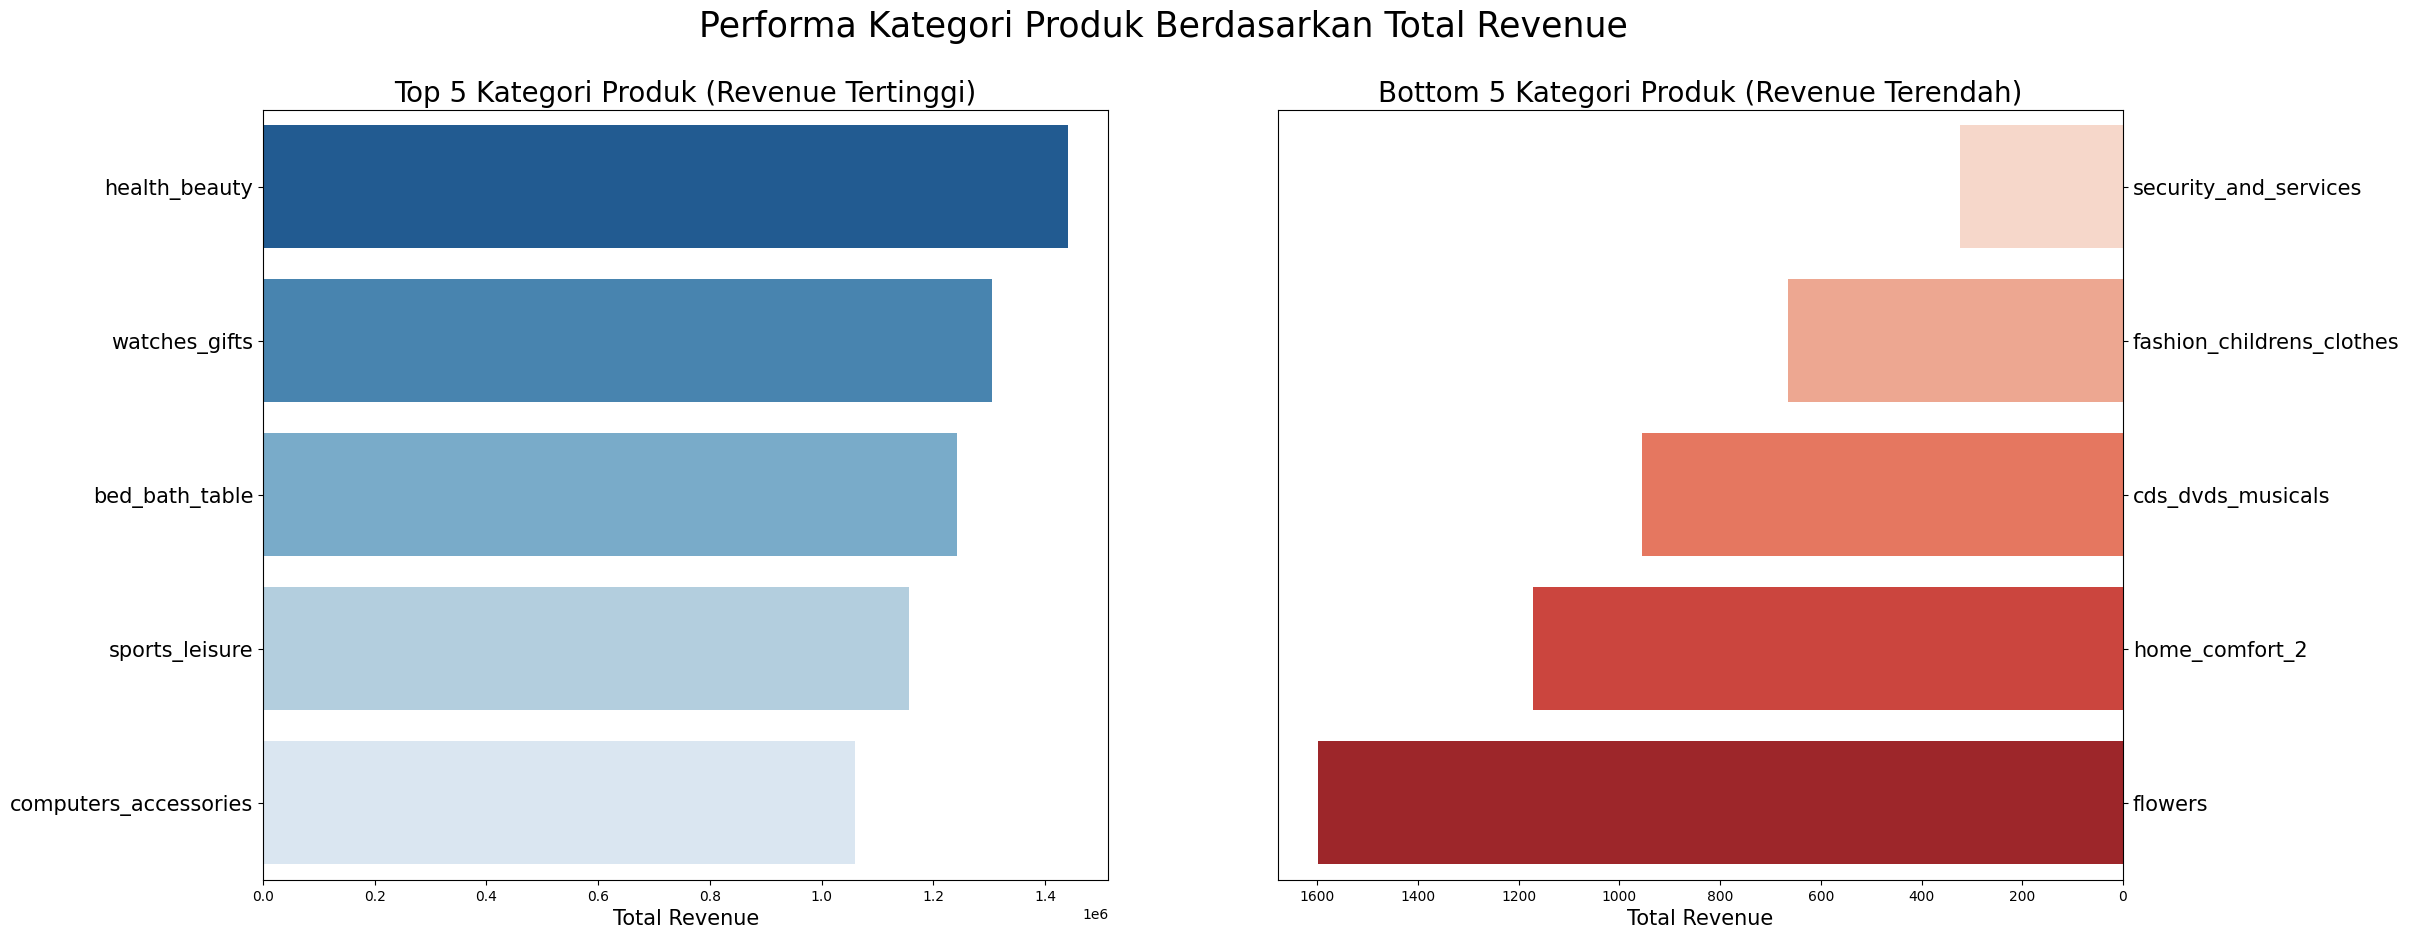

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualisasi Pertanyaan 1: Performa Kategori Produk ---

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Top 5 Categories
sns.barplot(x="revenue", y="category", data=category_revenue.head(5), palette="Blues_r", ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue", fontsize=15)
ax[0].set_title("Top 5 Kategori Produk (Revenue Tertinggi)", loc="center", fontsize=20)
ax[0].tick_params(axis='y', labelsize=15)

# Bottom 5 Categories
sns.barplot(x="revenue", y="category", data=category_revenue.sort_values(by="revenue", ascending=True).head(5), palette="Reds", ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue", fontsize=15)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Bottom 5 Kategori Produk (Revenue Terendah)", loc="center", fontsize=20)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Performa Kategori Produk Berdasarkan Total Revenue", fontsize=25)
plt.show()

### Pertanyaan 2:

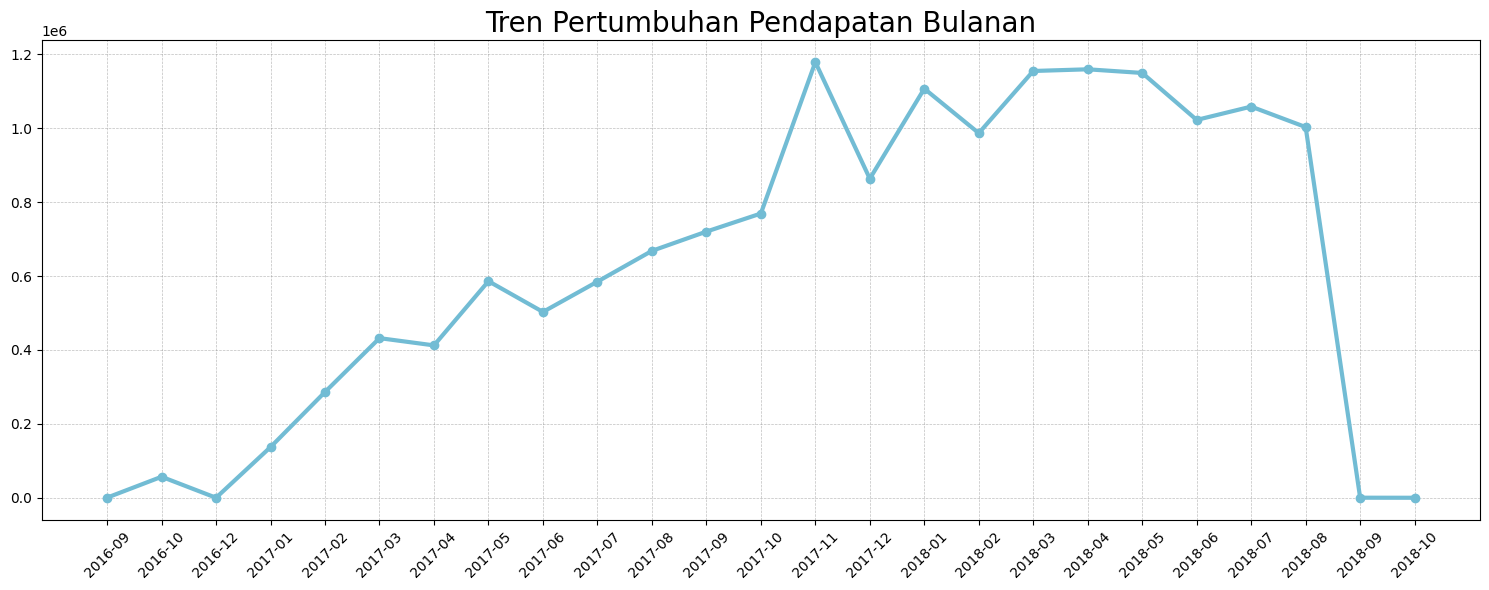

In [19]:
plt.figure(figsize=(15, 6))
plt.plot(
    monthly_trend["order_month"],
    monthly_trend["revenue"],
    marker='o',
    linewidth=3,
    color="#72BCD4"
)

plt.title("Tren Pertumbuhan Pendapatan Bulanan", loc="center", fontsize=20)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

```markdown
**Insight:**
- **Kategori Produk:** Kategori 'health_beauty' dan 'watches_gifts' merupakan kontributor pendapatan terbesar. Sebaliknya, kategori seperti 'security_and_services' dan 'fashion_childrens_clothes' memberikan kontribusi terendah.
- **Tren Penjualan:** Terdapat lonjakan pendapatan yang sangat tajam pada bulan November 2017, yang kemungkinan besar dipicu oleh event Black Friday. Setelah itu, pendapatan cenderung stabil di level yang lebih tinggi dibandingkan tahun sebelumnya.
```

## Analisis Lanjutan (Opsional)

In [13]:
# RFM Analysis Sederhana
current_date = merged_df['order_purchase_timestamp'].max()
rfm_df = merged_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days,
    'order_id': 'nunique',
    'total_revenue': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']
display(rfm_df.head())

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


## Conclusion & Recommendation

```markdown
- **Conclusion pertanyaan 1:** Kategori produk dengan kontribusi revenue tertinggi adalah **health_beauty** (diikuti oleh watches_gifts), sedangkan yang terendah adalah **security_and_services**. Perbedaan nilai antara kategori teratas dan terbawah sangat signifikan, menunjukkan dominasi produk gaya hidup dan kesehatan.
- **Conclusion pertanyaan 2:** Tren penjualan bulanan menunjukkan pertumbuhan yang konsisten sejak awal 2017, dengan **puncak tertinggi terjadi pada November 2017**. Meskipun ada fluktuasi, performa penjualan di tahun 2018 secara umum jauh lebih baik dibandingkan periode awal dataset di tahun 2016.
```

**Rekomendasi Action Item:**
- Meningkatkan stok dan variasi pada kategori high-revenue.
- Melakukan kampanye khusus pada bulan-bulan yang secara historis memiliki tren rendah (seperti awal tahun).